This notebook creates the tradeoff plots for FLOPS vs RMSE and footprint vs RMSE.

In [ ]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

import logging
import json
import re
from matplotlib import gridspec
from matplotlib.patches import Patch
from typing import List,Dict, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import pickle as pkl
from force_regression.config.dataconfig import DataConfig
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from hydra import initialize_config_dir, compose
import force_regression.utils.configuration as lrc
import force_regression.utils.functions as fn
import force_regression.evaluation.compile_results as cr
from force_regression.models.snn import *
from configs.constants import *

print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}.')

logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/force_regression_snn/notebooks/analysis
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/force_regression_snn.


In [2]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = config['root_dir']
        root_results_dir = config['root_results_dir']

        subject_mappings = config['subject_mappings']
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Root directory from config: /Volumes/big usb drive/local Thin film forearm preprocessed


# Load data configuration

In [3]:
subject = "S1"
mvc = 15
emg_type = 'intra'
sign_mvc = 1
segment_hold=False

In [4]:
data_config = DataConfig(root_dir=root_dir,
                    root_results_dir = root_results_dir,
                    subject=fn.reverse_remap(subject, subject_mappings),
                    task_type="Trap", 
                    finger_type="Individual",
                    day="Day 1", mvc=mvc,
                    emg_type=emg_type,
                    subj_map=subject_mappings,
                    segment_hold=segment_hold,
                    verbose=False,
                    common_only=True,
                    images=True,
                    time_to_cut=1,
                    convreg_temp_data_dir='regression_data',
                    results_dir = 'output_files',
                    figs_dir = 'figures')
output_figures_dir = os.path.join(data_config.root_results_dir, data_config.figs_dir)
results_dir = 'output_files'

output_figures_dir

'/Volumes/big usb drive/force_regression_codeshare/figures'

In [5]:
num_mu_per_direction = {'S1': {'flex': 121, 'ext': 196}, 'S2': {'flex': 51, 'ext': 93}}
n_channels = 120
n_timesteps = 2793 # number of discrete timesteps per sample

# Load SNN configuration

In [6]:
# load SNN configuratio using hydra
abs_config_dir=os.path.abspath("../../configs/hydra")
with initialize_config_dir(version_base=None, config_dir=abs_config_dir):
    cfg_encoding = compose(config_name="snn",
                overrides=["decoder_type=encoding",
                            "logging.wandb.use_wandb=False",
                            ])
    cfg_leaky = compose(config_name="snn",
                  overrides=["decoder_type=leaky",
                            "logging.wandb.use_wandb=False",
                             ])
    cfg_spiking = compose(config_name="snn",
                  overrides=["decoder_type=spiking",
                            "logging.wandb.use_wandb=False",
                             ])
flat_encoding_config = lrc.flatten_hydra_config(cfg_encoding)
flat_leaky_config = lrc.flatten_hydra_config(cfg_leaky)
flat_spiking_config = lrc.flatten_hydra_config(cfg_spiking)



# Load RMSE results from different pipelines

In [7]:
def mask_torch_seed(df, torch_seed):
    """
    Masks the dataframe based on the given torch seed.
    """
    if torch_seed is None:
        df_seed = df[df[TORCH_SEED_COL].isnull()]
    else:
        df_seed = df[df[TORCH_SEED_COL] == torch_seed]
    return df_seed

In [8]:
def combine_metrics_df_for_topology(subjects:List[str],
                                    topologies:List[str],
                                    metrics_list:List[str],
                                    config:DataConfig,
                                    save_dfs:bool=False):
    """
    Combine the metrics dataframes for each topology and compute the mean and std for each metric 
    during inference
    """
    metrics_list_with_mean_std = [f"{metric}_mean" for metric in metrics_list] + [f"{metric}_std" for metric in metrics_list]
    snn_topologies_df = pd.DataFrame()
    all_samples_df = pd.DataFrame()

    selected_scale = 0.1
    selected_tau = 0.1
    selected_thr = 0.1
    for topology in topologies:
        topology_df = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                       data_type='metrics_df_cv_snn',
                                                       network_topology=f'{topology}',
                                                       results_dir=results_dir,
                                                       config=config)
        if topology == ENC_SHALLOW_LEAKY:
            topology_df = topology_df[(topology_df[ENC_ALIF_SCALE_COL] == selected_scale) & 
                                    (topology_df[ENC_THRESHOLD_TAU_COL] == selected_tau) & 
                                    (topology_df[ENC_SPK_THRESH1_COL]==selected_thr)&
                                    (topology_df[EPOCHS_COL] == 100)]

        topology_df_inf = topology_df[topology_df[MODE_COL] == 'inference']

        mean_metrics = topology_df_inf.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list].mean().reset_index()
        std_metrics = topology_df_inf.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list].std().reset_index()
        mean_std_metrics_df_per_direction = pd.merge(mean_metrics, std_metrics, on=[SUBJECT_COL, SIGN_MVC_COL], suffixes=('_mean', '_std'))
        
        # Get the mean and std across directions
        df_across_directions = mean_std_metrics_df_per_direction.groupby([SUBJECT_COL], as_index=False)[metrics_list_with_mean_std].mean()
        mean_std_metrics_df_per_direction[TOPOLOGY_COL] = topology
        snn_topologies_df = pd.concat([snn_topologies_df, mean_std_metrics_df_per_direction], ignore_index=True)
        topology_df_inf[TOPOLOGY_COL] = topology
        all_samples_df = pd.concat([all_samples_df, topology_df_inf], ignore_index=True)


        if save_dfs:
            file_prefix = f'{topology}_average_metrics_table_mvc_15'
            df_across_directions.to_csv(os.path.join(output_figures_dir,f"{file_prefix}.csv"), index=False)
            mean_std_metrics_df_per_direction.to_csv(os.path.join(output_figures_dir,f"{file_prefix}_per_direction.csv"), index=False)

    return snn_topologies_df, all_samples_df

In [9]:
subjects = ["S1","S2"]
metrics_list = [RMSE_TEST, R2_TEST, MAE_TEST]

# First load the OLS LR metrics
metrics_df_conv = cr.load_and_parse_df_data(subject_list=subjects,
                                            data_type='metrics_df',
                                            config=config,
                                            results_dir='output_files',
                                            is_multi=False)
metrics_df_conv = metrics_df_conv[(metrics_df_conv[EMG_COL]=='intra') & (metrics_df_conv[SEGMENT_HOLD_COL]==False) & (metrics_df_conv[INPUT_TYPE_COL]==INPUT_TYPE_SP_COUNT) & (metrics_df_conv[MVC_COL]==15)]


INFO:root:Loaded data for 2 subjects: ['S1' 'S2']
MVC:[15]
Window size: [0.08]
Overlap: [50]
Sign MVC: [-1  1]



metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl


In [10]:
# Second, load the RNN metrics
metrics_compiled_df_rnn = cr.load_and_parse_rnn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='metrics_df_cv_rnn',
                                                                    run_dir='RNN/torch_seeds',
                                                                    results_dir='output_files',
                                                                    config=config)

Loading data for subject S1 from /Volumes/big usb drive/force_regression_codeshare/results/S1/RNN/torch_seeds
Loading file: metrics_df_cv_rnn_vanilla_ep_100_seed_89_noise_None_ns_100_hidsize_5_expdecay_0.01_kernelsize_5_rnnbias_False_normalizeforce_True_fcout_False_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_rnn_gru_ep_100_seed_15_noise_None_ns_100_hidsize_5_expdecay_0.01_kernelsize_5_rnnbias_False_normalizeforce_True_fcout_True_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_rnn_vanilla_ep_100_seed_29_noise_None_ns_100_hidsize_5_expdecay_0.01_kernelsize_5_rnnbias_False_normalizeforce_True_fcout_False_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_rnn_gru_ep_100_seed_73_noise_None_ns_100_hidsize_5_expdecay_0.01_kernelsize_5_rnnbias_False_normalizeforce_True_fcout_True_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_rnn_vanilla_ep_100_seed_28_noise_None_ns_100_hidsize_5_expdecay_0.

In [11]:
# Compute the average RMSEs
metrics_list = [RMSE_TEST, R2_TEST, MAE_TEST]
aux_cols = [SUBJECT_COL, SIGN_MVC_COL, RNN_TYPE_COL]
metrics_map_rename = {'MAE_test': 'MAE_test_mean',
                      'RMSE_test':'RMSE_test_mean',
                      'R2_test': 'R2_test_mean'}

rnn_mean_metrics = metrics_compiled_df_rnn.groupby(aux_cols)[metrics_list].mean().reset_index()
rnn_std_metrics = metrics_compiled_df_rnn.groupby(aux_cols)[metrics_list].std().reset_index()
rnn_mean_std_df = pd.merge(rnn_mean_metrics, rnn_std_metrics, on=aux_cols, suffixes=('_mean', '_std'))
rnn_mean_std_df.rename(columns={'rnn_type': TOPOLOGY_COL}, inplace=True)

rnn_mean_std_df

,subject,sign_mvc,topology,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std
0,S1,-1,gru,2.275561,0.813211,1.521938,0.559149,0.096877,0.354729
1,S1,-1,vanilla,2.167927,0.825915,1.309790,0.683626,0.118055,0.441428
2,S1,1,gru,1.580879,0.906981,1.053237,0.282408,0.031258,0.193226
3,S1,1,vanilla,1.879347,0.866586,1.108416,0.461056,0.059964,0.231297
4,S2,-1,gru,2.136654,0.847544,1.482839,0.419639,0.065875,0.292427
5,S2,-1,vanilla,2.524703,0.790304,1.718988,0.543395,0.079454,0.402195
6,S2,1,gru,2.274915,0.808013,1.513994,0.898676,0.146530,0.657491
7,S2,1,vanilla,2.963931,0.677894,1.938082,1.108768,0.207456,0.722404


In [12]:
# Third, load the SNN metrics for the different pipelines and calulcate mean metrics
topologies =[ENC_SHALLOW_LEAKY, SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER]

snn_topologies_df, samples_df = combine_metrics_df_for_topology(subjects,
                                                                 topologies,
                                                                 metrics_list,
                                                                 config,
                                                                 save_dfs=False)

Loading data for subject S1 from /Volumes/big usb drive/force_regression_codeshare/results/S1/SNN/encoding_shallow_leaky
Loading file: metrics_df_cv_snn_ep_100_seed_8_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.01_encthresh2_0.01_encthresh3_0.01_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.4_encthresh2_0.4_encthresh3_0.4_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau

Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.5_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.01_encthresh2_0.01_encthresh3_0.01_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.5_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_73_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sig

Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.08_encthresh2_0.08_encthresh3_0.08_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loadi

Loading file: metrics_df_cv_snn_ep_100_seed_9_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_28_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_28_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_64_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_15_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_0_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_s

In [13]:
# Compute the average RMSEs
metrics_list_with_mean_std = [f"{metric}_mean" for metric in metrics_list] + [f"{metric}_std" for metric in metrics_list]

mean_metrics_cv = cr.compute_mean_sd_metric(metrics_df_conv, mvc=15)
mean_std_metrics_baseline = mean_metrics_cv.groupby([SUBJECT_COL, SIGN_MVC_COL])[metrics_list_with_mean_std].mean().reset_index()
mean_std_metrics_baseline[TOPOLOGY_COL] = 'baseline'
mean_std_metrics_baseline

,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology
0,S1,-1,2.155425,0.828471,1.244390,0.287417,0.056561,0.163959,baseline
1,S1,1,1.308488,0.935923,0.766264,0.231823,0.023695,0.204748,baseline
2,S2,-1,2.058558,0.857186,1.370122,0.285548,0.042493,0.118037,baseline
3,S2,1,2.206248,0.819499,1.350547,0.788316,0.111418,0.776744,baseline


In [14]:
# Concatenate the baseline metrics with the SNN metrics
topology_to_label = {
    ENC_SHALLOW_LEAKY: 'encoding + leaky',
    ENC_SHALLOW_SPIKING: 'encoding + spiking',
    SHALLOW_LEAKY: 'motor units + leaky',
    SHALLOW_SPIKING_DOUBLE_FILTER: 'motor units + spiking',
    'baseline (OLS LR)': 'OLS LR',
    'gru': 'RNN (GRU)',
    'vanilla': 'RNN (vanilla)'
}
snn_topologies_df['topology_label'] = snn_topologies_df[TOPOLOGY_COL].map(topology_to_label)
mean_std_metrics_baseline['topology_label'] = 'OLS LR'
rnn_mean_std_df['topology_label'] = rnn_mean_std_df[TOPOLOGY_COL].map(topology_to_label)
topology_metrics_df = pd.concat([snn_topologies_df, mean_std_metrics_baseline,
                                 rnn_mean_std_df], ignore_index=True)

# map sign mvc to direction
sign_mvc_to_direction = {1: 'flex', -1: 'ext'}
topology_metrics_df[DIR_COL] = topology_metrics_df[SIGN_MVC_COL].map(sign_mvc_to_direction)

In [15]:
topology_metrics_df

,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology,topology_label,direction
0,S1,-1,2.660534,0.711524,1.858926,1.297155,0.289525,0.890991,encoding_shallow_leaky,encoding + leaky,ext
1,S1,1,2.871439,0.618362,1.860175,1.809450,0.393458,1.195541,encoding_shallow_leaky,encoding + leaky,flex
2,S2,-1,2.481361,0.785981,1.892088,1.037882,0.159093,0.904348,encoding_shallow_leaky,encoding + leaky,ext
3,S2,1,3.338534,0.607822,2.369989,1.105862,0.216558,0.750772,encoding_shallow_leaky,encoding + leaky,flex
4,S1,-1,1.958299,0.870309,1.224972,0.382629,0.050485,0.344576,shallow_leaky,motor units + leaky,ext
5,S1,1,1.498565,0.919254,0.962427,0.382516,0.037286,0.231677,shallow_leaky,motor units + leaky,flex
6,S2,-1,2.157862,0.856126,1.569748,0.358911,0.038290,0.387426,shallow_leaky,motor units + leaky,ext
7,S2,1,2.465921,0.791434,1.708747,0.729109,0.106439,0.529522,shallow_leaky,motor units + leaky,flex
8,S1,-1,2.08117,0.845281,1.248878,0.672547,0.103235,0.485128,shallow_spiking_double_filter,motor units + spiking,ext
9,S1,1,1.475492,0.922594,0.945407,0.243836,0.028362,0.222296,shallow_spiking_double_filter,motor units + spiking,flex


# Extract FLOPs/SYNOPs 

Since some of the operations are extracted from Tensorboard logs and others calculated, I manually create a matching df to the Tables in Suppplementary Materials.

In [16]:
import pandas as pd

data = [
    # Subject, Decoder, Direction, Dense_MOp, Eff_MAC_Op, Eff_AC_Op, Memory_MiB, CPU_s

    # S1

    ["S1", "SNN (LI)", "Flex", 1.690, 6.40e2, 3.30e4, "3.82/3.82", "0.434/0.427"],
    ["S1", "SNN (LI)", "Ext",  2.737, 1.30e3, 6.10e4, "5.43/5.42", "0.443/0.426"],

    ["S1", "SNN (LIF)", "Flex", 1.760, 6.40e2, 3.40e4, "5.60/5.59", "0.979/0.935"],
    ["S1", "SNN (LIF)", "Ext",  2.807, 1.30e3, 6.20e4, "7.21/7.20", "1.055/0.946"],

    ["S1", "Encoding SNN", "Flex", 41.895, 3.35e5, 1.77e5, "64.97/64.88", "1.511/1.306"],
    ["S1", "Encoding SNN", "Ext",  41.895, 3.35e5, 2.24e5, "65.17/64.90", "1.624/1.324"],


    # S2
    ["S2", "SNN (LI)", "Flex", 0.712, 9.30e1, 1.30e4, "2.33/2.33", "1.320/0.617"],
    ["S2", "SNN (LI)", "Ext",  1.299, 1.04e3, 2.60e4, "3.23/3.22", "0.439/0.429"],

    ["S2", "SNN (LIF)", "Flex", 0.782, 9.30e1, 1.40e4, "4.12/4.11", "1.105/0.954"],
    ["S2", "SNN (LIF)", "Ext",  1.369, 1.04e3, 2.70e4, "5.00/4.99", "0.958/0.927"],

    ["S2", "Encoding SNN", "Flex", 41.895, 3.35e5, 7.00e4, "64.98/64.68", "1.327/1.288"],
    ["S2", "Encoding SNN", "Ext",  41.895, 3.33e5, 1.19e5, "64.90/64.72", "1.324/1.278"],
]

columns = [
    "Subject",
    "Decoder",
    "Direction",
    "Dense_SynOps_MOp",
    "Eff_MACs_Op",
    "Eff_ACs_Op",
    "Peak_Avg_Memory_MiB",
    "Peak_Avg_CPU_s"
]

snn_ressources_df = pd.DataFrame(data, columns=columns)

# split the complex columns into separate columns for peak and average
snn_ressources_df[['Peak_Memory_MiB', 'Avg_Memory_MiB']] = snn_ressources_df['Peak_Avg_Memory_MiB'].str.split('/', expand=True)
snn_ressources_df[['Peak_CPU_s', 'Avg_CPU_s']] = snn_ressources_df['Peak_Avg_CPU_s'].str.split('/', expand=True)
snn_ressources_df.drop(columns=['Peak_Avg_Memory_MiB', 'Peak_Avg_CPU_s'], inplace=True)
snn_ressources_df

,Subject,Decoder,Direction,Dense_SynOps_MOp,Eff_MACs_Op,Eff_ACs_Op,Peak_Memory_MiB,Avg_Memory_MiB,Peak_CPU_s,Avg_CPU_s
0,S1,SNN (LI),Flex,1.690,640.0,33000.0,3.82,3.82,0.434,0.427
1,S1,SNN (LI),Ext,2.737,1300.0,61000.0,5.43,5.42,0.443,0.426
2,S1,SNN (LIF),Flex,1.760,640.0,34000.0,5.60,5.59,0.979,0.935
3,S1,SNN (LIF),Ext,2.807,1300.0,62000.0,7.21,7.20,1.055,0.946
4,S1,Encoding SNN,Flex,41.895,335000.0,177000.0,64.97,64.88,1.511,1.306
5,S1,Encoding SNN,Ext,41.895,335000.0,224000.0,65.17,64.90,1.624,1.324
6,S2,SNN (LI),Flex,0.712,93.0,13000.0,2.33,2.33,1.320,0.617
7,S2,SNN (LI),Ext,1.299,1040.0,26000.0,3.23,3.22,0.439,0.429
8,S2,SNN (LIF),Flex,0.782,93.0,14000.0,4.12,4.11,1.105,0.954
9,S2,SNN (LIF),Ext,1.369,1040.0,27000.0,5.00,4.99,0.958,0.927


In [17]:
topology_to_label = {
    ENC_SHALLOW_LEAKY: 'encoding + leaky',
    ENC_SHALLOW_SPIKING: 'encoding + spiking',
    SHALLOW_LEAKY: 'motor units + leaky',
    SHALLOW_SPIKING_DOUBLE_FILTER: 'motor units + spiking',
    'baseline (OLS LR)': 'OLS LR',
    'OLS LR': 'OLS LR',
    'RNN (GRU)': 'RNN (GRU)',
    'RNN (vanilla)': 'RNN (vanilla)',
    'gru': 'RNN (GRU)',
    'vanilla': 'RNN (vanilla)'
}
rows = [
    # --- SNN summary table (Total Eff. SynOps, already in kOp) ---
    ["S1", 'motor units + leaky',  "flex", 34.28],
    ["S1", 'motor units + leaky',  "ext",  63.60],
    ["S1", 'motor units + spiking', "flex", 35.28],
    ["S1", 'motor units + spiking', "ext",  64.60],
    ["S1", "encoding + leaky",   "flex", 847.00],
    ["S1", "encoding + leaky",   "ext",  894.00],

    ["S2", 'motor units + leaky',  "flex", 13.19],
    ["S2", 'motor units + leaky',  "ext",  28.08],
    ["S2", 'motor units + spiking', "flex", 14.19],
    ["S2", 'motor units + spiking', "ext",  29.08],
    ["S2", "encoding + leaky",   "flex", 740.00],
    ["S2", "encoding + leaky",   "ext",  785.00],

    # --- OLS LR baseline (Total FLOPs in kOp) ---
    ["S1", "OLS LR", "flex", 857.033],
    ["S1", "OLS LR", "ext",  1393.698],
    ["S2", "OLS LR", "flex", 360.838],
    ["S2", "OLS LR", "ext",  659.168],

    # --- RNN baselines (Total FLOPs in MOp -> convert to kOp by *1000) ---
    ["S1", "RNN (vanilla)",   "flex", 6.90 * 1000],
    ["S1", "RNN (vanilla)",   "ext",  11.09 * 1000],
    ["S1", "RNN (GRU)",  "flex", 14.09 * 1000],
    ["S1", "RNN (GRU)",  "ext",  22.48 * 1000],

    ["S2", "RNN (vanilla)",   "flex", 4.55 * 1000],
    ["S2", "RNN (vanilla)",   "ext",  8.08 * 1000],
    ["S2", "RNN (GRU)",  "flex", 11.12 * 1000],
    ["S2", "RNN (GRU)",  "ext",  19.33 * 1000],
]

df_total_flops = pd.DataFrame(
    rows,
    columns=[SUBJECT_COL, 'topology_label', DIR_COL, "Total_FLOPs_kOp_decoder"]
)


# Adding the MAC operation for the decomposition stage: n_motor_units x n_channels (120) x timesteps (2793)
# adding the motor units column
df_total_flops['num_mu'] = df_total_flops.apply(lambda row: num_mu_per_direction[row['subject']][row['direction']], axis=1)
# add a column for the total memory including the separation matrices: 120 channels and 4 bytes
df_total_flops['Total_decomp_MACs_Op'] = df_total_flops['num_mu'] * n_channels * n_timesteps
# set the decomposition size to 0 for the ENC_SHALLOW_LEAKY topology
df_total_flops.loc[df_total_flops['topology_label'] == topology_to_label[ENC_SHALLOW_LEAKY],'Total_decomp_MACs_Op'] = 0
df_total_flops['Total_decomp_FLOPs_kOp'] = df_total_flops['Total_decomp_MACs_Op'] * 2 / 1000

df_total_flops['Total_FLOPs_kOp'] = df_total_flops['Total_decomp_FLOPs_kOp'] + df_total_flops['Total_FLOPs_kOp_decoder'] 
df_total_flops['ratio_decomp_to_total'] = df_total_flops['Total_decomp_FLOPs_kOp']/df_total_flops['Total_FLOPs_kOp']
df_total_flops['ratio_decomp_to_decoder'] = df_total_flops['Total_decomp_FLOPs_kOp']/df_total_flops['Total_FLOPs_kOp_decoder']

df_total_flops.groupby([SUBJECT_COL, 'topology_label'])['Total_FLOPs_kOp'].count()
df_total_flops

,subject,topology_label,direction,Total_FLOPs_kOp_decoder,num_mu,Total_decomp_MACs_Op,Total_decomp_FLOPs_kOp,Total_FLOPs_kOp,ratio_decomp_to_total,ratio_decomp_to_decoder
0,S1,motor units + leaky,flex,34.280,121,40554360,81108.72,81143.000,0.999578,2366.065344
1,S1,motor units + leaky,ext,63.600,196,65691360,131382.72,131446.320,0.999516,2065.766038
2,S1,motor units + spiking,flex,35.280,121,40554360,81108.72,81144.000,0.999565,2299.000000
3,S1,motor units + spiking,ext,64.600,196,65691360,131382.72,131447.320,0.999509,2033.788235
4,S1,encoding + leaky,flex,847.000,121,0,0.00,847.000,0.000000,0.000000
5,S1,encoding + leaky,ext,894.000,196,0,0.00,894.000,0.000000,0.000000
6,S2,motor units + leaky,flex,13.190,51,17093160,34186.32,34199.510,0.999614,2591.836240
7,S2,motor units + leaky,ext,28.080,93,31169880,62339.76,62367.840,0.999550,2220.076923
8,S2,motor units + spiking,flex,14.190,51,17093160,34186.32,34200.510,0.999585,2409.183932
9,S2,motor units + spiking,ext,29.080,93,31169880,62339.76,62368.840,0.999534,2143.733150


# Load Footprint

In [18]:
network_statedict_path = os.path.dirname(data_config.snn_temp_data_path)
# list files
for filename in os.listdir(network_statedict_path):
    if filename.endswith(".pt"):
        print(f"Found network state dict: {filename}")

Found network state dict: S1_mvc_15_ext_networkparam_topology_shallow_leaky.pt
Found network state dict: S2_mvc_15_ext_networkparam_topology_encoding_shallow_leaky.pt
Found network state dict: S1_mvc_15_flex_networkparam_topology_shallow_spiking_double_filter.pt
Found network state dict: S2_mvc_15_ext_networkparam_topology_shallow_leaky.pt
Found network state dict: S1_mvc_15_ext_networkparam_topology_encoding_shallow_leaky.pt
Found network state dict: S2_mvc_15_flex_networkparam_topology_shallow_leaky.pt
Found network state dict: S2_mvc_15_ext_networkparam_topology_shallow_spiking_double_filter.pt
Found network state dict: S1_mvc_15_flex_networkparam_topology_shallow_leaky.pt
Found network state dict: S2_mvc_15_flex_networkparam_topology_shallow_spiking_double_filter.pt
Found network state dict: S1_mvc_15_ext_networkparam_topology_shallow_spiking_double_filter.pt
Found network state dict: S1_mvc_15_flex_networkparam_topology_encoding_shallow_leaky.pt
Found network state dict: S2_mvc_15

In [19]:
# from filename parse subject, mvc, direction, topology
def parse_filename(filename: str) -> Tuple[str, int, str, str]:
    match = re.search(r"(\w+)_mvc_(\d+)_(\w+)_networkparam_topology_(\w+)", filename)
    if match:
        subject = match.group(1)
        mvc = int(match.group(2))
        direction = match.group(3)
        topology = match.group(4)
        print(f"Parsed from filename - Subject: {subject}, MVC: {mvc}, Direction: {direction}, Topology: {topology}")
    return subject, mvc, direction, topology

In [20]:
# list files
topology_footprint_df = pd.DataFrame(columns=[SUBJECT_COL, TOPOLOGY_COL, DIR_COL, 'param_name', 'num_params','param_size_in_bytes',
                           'num_nonzero','nonzero_param_size_in_bytes', 'num_trainable_params'])
trainable_layers = {SHALLOW_LEAKY: ['fc1.weight', 'fc1.bias'],
                    SHALLOW_SPIKING_DOUBLE_FILTER: ['fc1.weight', 'fc1.bias', 'lif1.beta'],
                    ENC_SHALLOW_LEAKY: ['fc1.weight', 'fc1.bias']}
ignored_layers = ['graded_spikes_factor', 'reset_mechanism_val']


for filename in os.listdir(network_statedict_path):
    if not filename.endswith(".pt"):
        continue
    subject, mvc, direction, topology = parse_filename(filename)
    # load network state dict
    network_state_dict = torch.load(os.path.join(network_statedict_path, filename))
    network_state_dict_keys = list(network_state_dict.keys())

    for param_tensor in network_state_dict_keys:
        num_trainable_params = 0
        if param_tensor in  trainable_layers[topology]:
            num_trainable_params = network_state_dict[param_tensor].numel()
        # if substring ignored_layers in param_tensor
        if any(ignored_layer in param_tensor for ignored_layer in ignored_layers):
            continue
        topology_footprint_df.loc[len(topology_footprint_df)] = [subject, topology, direction, param_tensor,
            network_state_dict[param_tensor].numel(),
            network_state_dict[param_tensor].numel() * network_state_dict[param_tensor].element_size(),
            torch.count_nonzero(network_state_dict[param_tensor]).item(),
            torch.count_nonzero(network_state_dict[param_tensor]).item() * network_state_dict[param_tensor].element_size(),
            num_trainable_params
            ]
        


Parsed from filename - Subject: S1, MVC: 15, Direction: ext, Topology: shallow_leaky
Parsed from filename - Subject: S2, MVC: 15, Direction: ext, Topology: encoding_shallow_leaky
Parsed from filename - Subject: S1, MVC: 15, Direction: flex, Topology: shallow_spiking_double_filter
Parsed from filename - Subject: S2, MVC: 15, Direction: ext, Topology: shallow_leaky
Parsed from filename - Subject: S1, MVC: 15, Direction: ext, Topology: encoding_shallow_leaky
Parsed from filename - Subject: S2, MVC: 15, Direction: flex, Topology: shallow_leaky
Parsed from filename - Subject: S2, MVC: 15, Direction: ext, Topology: shallow_spiking_double_filter
Parsed from filename - Subject: S1, MVC: 15, Direction: flex, Topology: shallow_leaky
Parsed from filename - Subject: S2, MVC: 15, Direction: flex, Topology: shallow_spiking_double_filter
Parsed from filename - Subject: S1, MVC: 15, Direction: ext, Topology: shallow_spiking_double_filter
Parsed from filename - Subject: S1, MVC: 15, Direction: flex, To

In [21]:
topology_footprint_df

,subject,topology,direction,param_name,num_params,param_size_in_bytes,num_nonzero,nonzero_param_size_in_bytes,num_trainable_params
0,S1,shallow_leaky,ext,fc1.weight,980,3920,980,3920,980
1,S1,shallow_leaky,ext,fc1.bias,5,20,5,20,5
2,S1,shallow_leaky,ext,lif1.threshold,1,8,1,8,0
3,S1,shallow_leaky,ext,lif1.beta,1,4,1,4,0
4,S1,shallow_leaky,ext,lif1.alpha,1,4,1,4,0
...,...,...,...,...,...,...,...,...,...
99,S2,encoding_shallow_leaky,flex,lif1.threshold,1,8,1,8,0
100,S2,encoding_shallow_leaky,flex,lif1.beta,1,4,1,4,0
101,S2,encoding_shallow_leaky,flex,lif1.alpha,1,4,1,4,0
102,S2,encoding_shallow_leaky,flex,first_filter.threshold,1,8,1,8,0


In [22]:
def post_process_footprint_df(topology_footprint_df:pd.DataFrame) -> pd.DataFrame:
    """
        Post-process the loaded footprint dataframe to only keep the parameters that are relevant for the comparison between the 
        different topologies. This is because some parameters are only implementation hacks
        and do not reflect the actual differences between the topologies. 
        For example, the threshold parameters in the leaky neurons are only there to make them work with the same code as the spiking neurons, 
        but they are not actually used during inference since they are fixed to a very high value.
        Note: there are two additional parameters for the encoding topology that were not saved: the adaptation time constant which was fixed
            for all encoding neurons (hence counts as 1 parameter), and the encoding neurons' fixed beta parameter which also counts as 1 parameter.
    """
    # post-processing the loaded footprint df
    considered_parameters = {SHALLOW_LEAKY: ['fc1.weight', 'fc1.bias', 'lif1.alpha', 'lif1.beta'],
                            SHALLOW_SPIKING_DOUBLE_FILTER: ['fc1.weight', 'fc1.bias', 'lif1.alpha', 'lif1.beta', 'lif1.threshold', 'fc2.weight', 'first_filter.beta', 'second_filter.beta'],
                            ENC_SHALLOW_LEAKY: ['enc_fc.weight', 'encoding_layer.threshold', 'fc1.weight','lif1.alpha','lif1.beta','first_filter.beta']}
    # For encoding manually add the parmaeters for the adaptation and the encoding layer fixed beta
    topology_footprint_df_post = pd.DataFrame()

    for topology in topologies:
        topology_df = topology_footprint_df[topology_footprint_df['topology']==topology]
        topology_df_post = topology_df[topology_df['param_name'].isin(considered_parameters[topology])]
        topology_footprint_df_post = pd.concat([topology_footprint_df_post, topology_df_post], ignore_index=True)
    return topology_footprint_df_post


In [23]:
topology_footprint_df_post = post_process_footprint_df(topology_footprint_df)
topology_footprint_df_post.groupby([SUBJECT_COL, DIR_COL, TOPOLOGY_COL])['num_params'].sum()

# add +2 parameters for the encoding topology to account for the adaptation time constant and the encoding layer fixed beta
total_footprint_df = topology_footprint_df_post.groupby([SUBJECT_COL, DIR_COL, TOPOLOGY_COL],as_index=False)['num_params'].sum()
total_footprint_df.loc[total_footprint_df[TOPOLOGY_COL]==ENC_SHALLOW_LEAKY, 'num_params'] += 2
total_footprint_df

,subject,direction,topology,num_params
0,S1,ext,encoding_shallow_leaky,15125
1,S1,ext,shallow_leaky,987
2,S1,ext,shallow_spiking_double_filter,1019
3,S1,flex,encoding_shallow_leaky,15125
4,S1,flex,shallow_leaky,612
5,S1,flex,shallow_spiking_double_filter,644
6,S2,ext,encoding_shallow_leaky,15125
7,S2,ext,shallow_leaky,472
8,S2,ext,shallow_spiking_double_filter,504
9,S2,flex,encoding_shallow_leaky,15125


In [24]:
# Adding the footprint for the OLS LR baseline, RNN and GRU
baseline_rows = [
   # ---------------- S1 ----------------
    # Baselines
    ["S1", r"OLS LR", "flex", 605],
    ["S1", r"OLS LR", "ext",  980],
    ["S1", r"RNN (vanilla)", "flex", 1235],
    ["S1", r"RNN (vanilla)", "ext",  1985],
    ["S1", r"RNN (GRU)", "flex", 2520],
    ["S1", r"RNN (GRU)", "ext",  4020],

    # ---------------- S2 ----------------
    # Baselines
    ["S2", r"OLS LR", "flex", 255],
    ["S2", r"OLS LR", "ext",  465],
    ["S2", r"RNN (vanilla)", "flex", 535],
    ["S2", r"RNN (vanilla)", "ext",  955],
    ["S2", r"RNN (GRU)", "flex", 1120],
    ["S2", r"RNN (GRU)", "ext",  1960],

]

total_footprint_df = pd.merge(total_footprint_df, pd.DataFrame(baseline_rows, columns=[SUBJECT_COL, TOPOLOGY_COL, DIR_COL, 'num_params']), on=[SUBJECT_COL, TOPOLOGY_COL, DIR_COL, 'num_params'], how='outer')
total_footprint_df['footprint_bytes'] = total_footprint_df['num_params'] * 4  # Assuming 32-bit floats (4 bytes)

# adding the motor units column
total_footprint_df['num_mu'] = total_footprint_df.apply(lambda row: num_mu_per_direction[row['subject']][row['direction']], axis=1)
# add a column for the total memory including the separation matrices: 120 channels and 4 bytes
total_footprint_df['decomp_bytes'] = total_footprint_df['num_mu'] * n_channels * 4 
# set the decomposition size to 0 for the ENC_SHALLOW_LEAKY topology
total_footprint_df.loc[
        total_footprint_df[TOPOLOGY_COL] == ENC_SHALLOW_LEAKY,'decomp_bytes'] = 0

total_footprint_df['total_footprint_bytes'] = total_footprint_df['footprint_bytes'] + total_footprint_df['decomp_bytes']
total_footprint_df['topology_label'] = total_footprint_df[TOPOLOGY_COL].map(topology_to_label)
total_footprint_df

,subject,direction,topology,num_params,footprint_bytes,num_mu,decomp_bytes,total_footprint_bytes,topology_label
0,S1,ext,encoding_shallow_leaky,15125,60500,196,0,60500,encoding + leaky
1,S1,ext,shallow_leaky,987,3948,196,94080,98028,motor units + leaky
2,S1,ext,shallow_spiking_double_filter,1019,4076,196,94080,98156,motor units + spiking
3,S1,flex,encoding_shallow_leaky,15125,60500,121,0,60500,encoding + leaky
4,S1,flex,shallow_leaky,612,2448,121,58080,60528,motor units + leaky
5,S1,flex,shallow_spiking_double_filter,644,2576,121,58080,60656,motor units + spiking
6,S2,ext,encoding_shallow_leaky,15125,60500,93,0,60500,encoding + leaky
7,S2,ext,shallow_leaky,472,1888,93,44640,46528,motor units + leaky
8,S2,ext,shallow_spiking_double_filter,504,2016,93,44640,46656,motor units + spiking
9,S2,flex,encoding_shallow_leaky,15125,60500,51,0,60500,encoding + leaky


# Create scatter plots: RMSE, footprint, computational cost

In [27]:
total_footprint_df['topology'].unique(), topology_metrics_df['topology_label'].unique()

(array(['encoding_shallow_leaky', 'shallow_leaky',
        'shallow_spiking_double_filter', 'OLS LR', 'RNN (vanilla)',
        'RNN (GRU)'], dtype=object),
 array(['encoding + leaky', 'motor units + leaky', 'motor units + spiking',
        'OLS LR', 'RNN (GRU)', 'RNN (vanilla)'], dtype=object))

In [154]:
topology_metrics_df.head()

,subject,sign_mvc,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std,topology,topology_label,direction
0,S1,-1,2.660534,0.711524,1.858926,1.297155,0.289525,0.890991,encoding_shallow_leaky,encoding + leaky,ext
1,S1,1,2.871439,0.618362,1.860175,1.809450,0.393458,1.195541,encoding_shallow_leaky,encoding + leaky,flex
2,S2,-1,2.481361,0.785981,1.892088,1.037882,0.159093,0.904348,encoding_shallow_leaky,encoding + leaky,ext
3,S2,1,3.338534,0.607822,2.369989,1.105862,0.216558,0.750772,encoding_shallow_leaky,encoding + leaky,flex
4,S1,-1,1.958299,0.870309,1.224972,0.382629,0.050485,0.344576,shallow_leaky,motor units + leaky,ext


In [28]:
def plot_rmse_vs_footprint_and_flops(total_footprint_df: pd.DataFrame,
                                      df_total_flops: pd.DataFrame,
                                      topology_metrics_df: pd.DataFrame,
                                      rmse_col: str = 'RMSE_test_mean',
                                      flops_col: str = 'Total_FLOPs_kOp',
                                      flops_y_lim:list[float] = [10, 10**5],
                                      save_fig: bool = False,
                                      footprint_col = 'total_footprint_bytes',
                                      output_figures_dir: str = None,
                                      fig_name: str = None):
    """
    For each subject, plot RMSE vs Footprint (left) and RMSE vs FLOPs (right).
    Color = topology, marker shape = direction.
    """
    sign_mvc_to_dir = {1: 'flex', -1: 'ext'}
    topology_metrics_df = topology_metrics_df.copy()
    topology_metrics_df[DIR_COL] = topology_metrics_df[SIGN_MVC_COL].map(sign_mvc_to_dir)
    
    merge_keys = [SUBJECT_COL, 'topology_label', DIR_COL]
    merged = pd.merge(total_footprint_df, df_total_flops, on=merge_keys)
    merged = pd.merge(merged, topology_metrics_df, on=merge_keys)
    merged[rmse_col] = pd.to_numeric(merged[rmse_col], errors='coerce')
    
    topology_colors = {
        'motor units + leaky': sns.color_palette(palette='Accent')[0],
        'motor units + spiking': COLORS['belize'],
        'encoding + leaky': COLORS['burgundy'],
        'OLS LR': '#FF6F5C',
        'RNN (vanilla)': COLORS['mustard'],
        'RNN (GRU)': COLORS['clouds']
    }
    
    direction_markers = {'flex': 'o', 'ext': '^'}
    subjects = merged[SUBJECT_COL].unique()
    
    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(nrows=len(subjects), ncols=2, hspace=0.4, wspace=0.3)
    
    for row, subject in enumerate(subjects):
        subject_data = merged[merged[SUBJECT_COL] == subject]
        
        for col, (y_col, y_label) in enumerate([
            (footprint_col, 'Footprint (kbytes)'),
            (flops_col, 'FLOPs/SynOps (kOp)')
        ]):
            ax = fig.add_subplot(gs[row, col])
            
            for topology in subject_data['topology_label'].unique():
                for direction in subject_data[DIR_COL].unique():
                    mask = (subject_data['topology_label'] == topology) & (subject_data[DIR_COL] == direction)
                    subset = subject_data[mask]
                    if subset.empty:
                        continue
                    
                    color = topology_colors.get(topology, COLORS['midnight_blue'])
                    marker = direction_markers.get(direction, 'o')
                    label = f"{topology} - {direction.capitalize()}"
                    if y_col == footprint_col:
                        subset[y_col] = subset[y_col] / 1024  # convert bytes to kbytes
                    ax.scatter(subset[rmse_col], subset[y_col],
                               s=50, c=color, marker=marker,
                               alpha=0.7, edgecolors=COLORS['midnight_blue'],
                               linewidths=0.8, label=label, zorder=3)
            
            ax.set_ylabel(y_label, fontsize=LABEL_FONTSIZE)
            ax.set_xlabel("RMSE (%MVC)", fontsize=LABEL_FONTSIZE)
            if y_col == footprint_col:
                ax.set_ylim([20,120])
                #  ax.set_ylim([500,10**6])
            if y_col == flops_col:
                # ax.set_ylim([10, 10**5]) 
                ax.set_ylim(flops_y_lim)
                ax.set_yscale('log')
            ax.set_title(f"Subject {subject.split('S')[-1]}", fontsize=TITLE_FONTSIZE)

            ax.set_xlim([1,3.5])

            ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
            sns.despine(ax=ax)
    

        # Legend for directions (marker shape)
    direction_handles = [
        Line2D([0], [0], marker='o', color='w', label='flexion',
               markerfacecolor='w', markeredgecolor=COLORS['midnight_blue'], markersize=8),
        Line2D([0], [0], marker='^', color='w', label='extension',
               markerfacecolor='w', markeredgecolor=COLORS['midnight_blue'], markersize=8),
        Line2D([0], [0], marker='', color='w', label=''),
        # Line2D([0], [0], marker='', color='w', label=''),
        Line2D([0], [0], marker='', color='w', label='')

    ]
    
    # Legend for topologies (color) - ordered
    topology_order = ['OLS LR', 'RNN (vanilla)', 'RNN (GRU)', 
                      'motor units + leaky', 'motor units + spiking', 'encoding + leaky']
    topology_handles = [
        Patch(facecolor=topology_colors[topo], edgecolor=COLORS['midnight_blue'], label=topo, alpha=0.7)
        for topo in topology_order
        if topo in merged['topology_label'].unique()
    ]
    legend_handles = direction_handles + topology_handles

    legend2 = ax.legend(handles=legend_handles,
                        title='Movement Direction',
                        
                        bbox_to_anchor=(2, 2), frameon=False, borderaxespad=0,
                        fontsize=LABEL_FONTSIZE)
    legend2.get_title().set_ha('left')
    legend2._legend_box.align = 'left'
    
    fig.tight_layout()

    if save_fig and output_figures_dir:
        if fig_name is None:
            fig_name = f"rmse_vs_footprint_and_flops_legend_right_{footprint_col}_{flops_col}.png"
        fig_path = os.path.join(output_figures_dir, fig_name)
        plt.savefig(fig_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved at {fig_path}")
    
    return fig


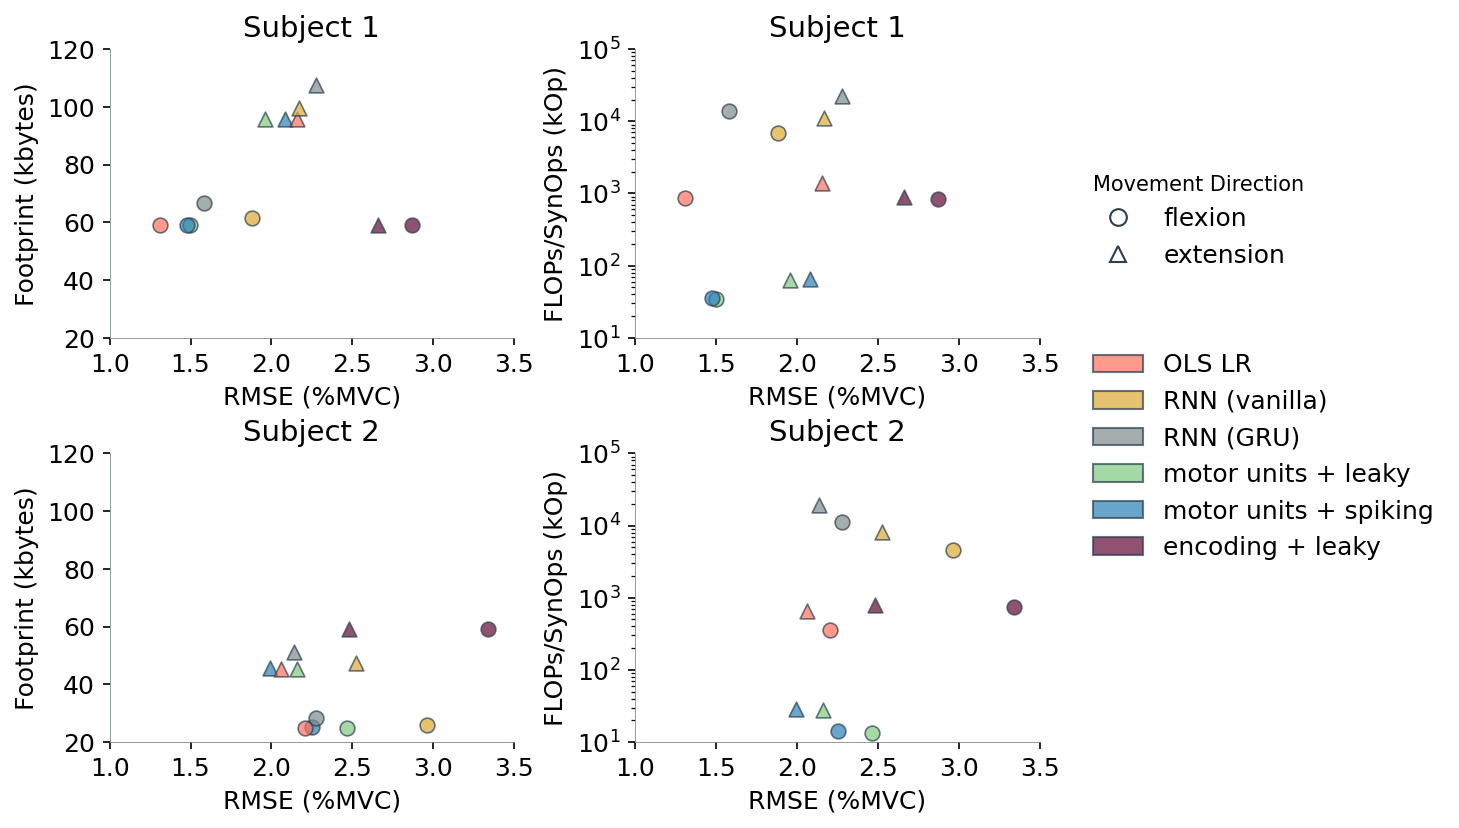

In [30]:
fig = plot_rmse_vs_footprint_and_flops(
    total_footprint_df,
    df_total_flops,
    topology_metrics_df,
    save_fig=False,
    output_figures_dir=output_figures_dir,
    footprint_col = 'total_footprint_bytes',  # 'total_footprint_bytes': includes the decomposition matrices | 'footprint_bytes': only the model parameters
    flops_col = 'Total_FLOPs_kOp_decoder' , # 'Total_FLOPs_kOp' includes the decomposition costs | 'Total_FLOPs_kOp_decoder': only the decoder and its associated stage 
)



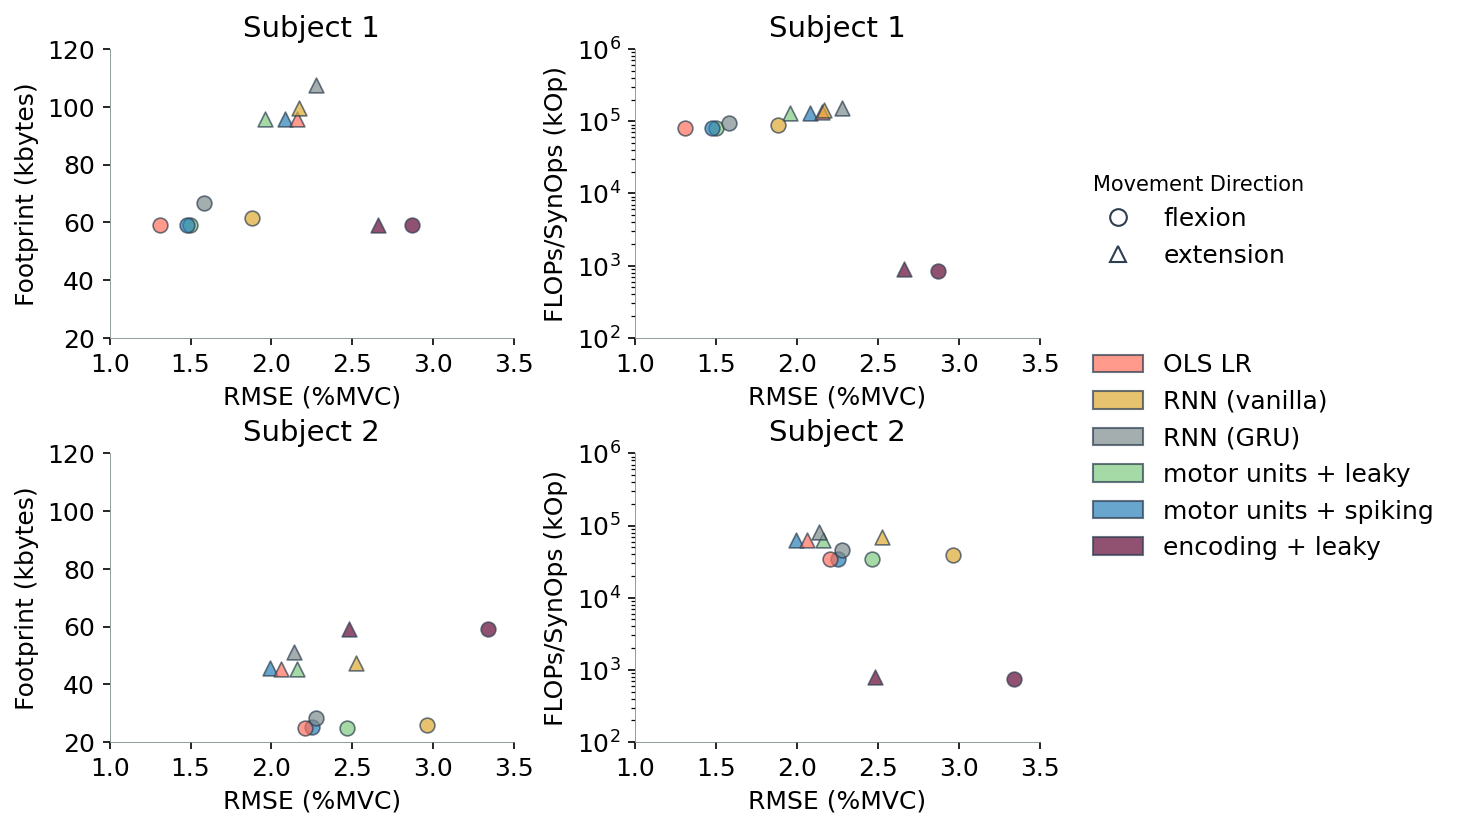

In [ ]:
fig = plot_rmse_vs_footprint_and_flops(
    total_footprint_df,
    df_total_flops,
    topology_metrics_df,
    save_fig=False,
    output_figures_dir=output_figures_dir,
    flops_y_lim=[10**2, 10**6],
    footprint_col = 'total_footprint_bytes', 
    flops_col = 'Total_FLOPs_kOp' ,
)
